# Laboratorio 3

## Cálculo de Accesibilidades Gravitacionales

Ayudante: Janus Leonhardt | jaleonhardt@uc.cl  

Profesor: Ricardo Hurtubia | rhurtubia@uc.cl

## Objetivos del Laboratorio:

1. Consolidar la información de las celdas enriquecida con datos catastrales, censales y paraderos para calcular accesibilidades gravitacionales.

2. Explicar el concepto de la función de impedancia y cómo se aplica en el cálculo de accesibilidades gravitacionales.

3. Introducir herramientas para generar matrices de costo/tiempo/distancia entre celdas (p.ej., OSRM), y ejemplificar cómo integrar dichos valores en el modelo de accesibilidad gravitacional.

4. Guardar los resultados de la estimación de accesibilidades en un archivo GeoJSON para su uso posterior.

---

### 1. Repaso del Laboratorio 2

En el **Laboratorio 2**, aprendimos sobre la integración de información geoespacial a nuestras celdas, a partir de los métodos *overlay* y *sjoin* de GeoPandas, creando un GeoDataFrame de celdas con variables como `personas`, `hogares`, `n_paraderos`, etc. A partir de esta base de datos consolidada, en el Laboratorio 3 nos centraremos en el **cálculo de accesibilidades gravitacionales**.

---

## 2. Instalación y Configuración del Entorno de Trabajo

### Requisitos Previos

- Python 3.7 o superior

- Jupyter Notebook

- **Librerías de Python**:

  - pandas  
  - geopandas  
  - shapely  
  - h3  
  - matplotlib  
  - folium  
  - mapclassify  
  - seaborn
  - **requests**

### Instalación de Librerías

Recordemos que las librerías deben haber quedado correctamente instaladas en nuestro entorno virtual (`.conda` o `.venv`) creado en el Laboratorio 1. En caso contrario, se debe ejecutar la siguiente línea de código.

`!pip install pandas geopandas shapely h3 matplotlib folium mapclassify seaborn requests`

In [2]:
# instalar las librerías faltantes
!pip install requests

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


---

## 3. Carga de Datos Previos

En este laboratorio, partiremos desde los archivos generados en el Laboratorio 2, los cuales contienen la información catastral relacionada con las celdas y sus atributos del entorno construido que integramos de fuentes de datos externas (Censo 2017, SIEDU).

- **`celdas.geojson`**: Contiene información geoespacial agregada por cada celda, incluyendo la geometría hexagonal y atributos del entorno construido que se obtienen de la agregación de las líneas de construcción y de otras fuentes de datos.

In [3]:
import pandas as pd
import geopandas as gpd
import numpy as np

# ajustes de visualización
pd.set_option('display.max_columns', None)

# cargar base territorial construida en el Lab 2
celdas = gpd.read_file("../lab_02/analisis_rancagua_machali.geojson")

print("Número de celdas:", len(celdas))
print("CRS:", celdas.crs)
print("Número de variables:", len(celdas.columns))

Número de celdas: 880
CRS: EPSG:4326
Número de variables: 61


In [4]:
# control de variables
variables_lab3 = [
    'h3',
    'personas',
    'viviendas',
    'hogares',
    'm2_comercio',
    'm2_departamento',
    'n_deporte_y_recreacion',
    'n_educacion_y_cultura',
    'm2_habitacional',
    'm2_industria',
    'm2_oficina',
    'n_salud',
    'n_paraderos'
]

for var in variables_lab3:
    print(f"{var}: {'OK' if var in celdas.columns else 'FALTA'}")

h3: OK
personas: OK
viviendas: OK
hogares: OK
m2_comercio: OK
m2_departamento: OK
n_deporte_y_recreacion: OK
n_educacion_y_cultura: OK
m2_habitacional: OK
m2_industria: OK
m2_oficina: OK
n_salud: OK
n_paraderos: OK


In [5]:
# revisamos el sistema de referencia de coordenadas
print(celdas.crs)

EPSG:4326


Recordar que lo ideal es que nuestros GeoDataFrame se encuentren en WGS84 (EPSG:4326) si vamos a mostrar mapas interactivos, o en un CRS proyectado (EPSG:32719) si calcularemos distancias en metros.

---

## 4. Introducción al Modelo Gravitacional de Accesibilidad

El modelo gravitacional de accesibilidad asume que la atracción de oportunidades (p. ej., población, empleos, comercio) decrece con el costo/distancia/tiempo para llegar a ellas. Sean $i, j$ las celdas de origen y destino, $m$ el modo de transporte (p. ej, automóvil, caminata, transporte público), $p$ el propósito/tipo de actividad/oportunidad (en este caso relacionadas con el uso de suelo), $N_{j}^{p}$ la cantidad/calidad de oportunidades de tipo $p$ en el celda $j$ y $F_{i,j}^{m}$ el valor de la función de impedancia que aplica entre la celda $i$ a $j$ en el modo $m$, entonces la accesibilidad de la celda $i$ en el modo $m$ a las oportunidades del tipo $p$ queda definida de la siguiente manera.


$acc_{i}^{m,p} = \sum_{j=1}^{J} N_{j}^{p} \cdot F_{i,j}^{m}$

### Ejemplo de Función de Impedancia (Exponencial)

La función de impedancia es un componente clave en el cálculo del modelo gravitacional de accesibilidad, ya que mide cómo disminuye la atracción de oportunidades en función del costo generalizado (e.g., tiempo, distancia o gasto) para alcanzarlas. Una de las formas más comunes de representar esta relación es mediante la función exponencial, definida a continuación.


$F_{i,j}^{m} = e^{\phi \cdot C_{i,j}^{m}}$


En este caso, $C_{i,j}^{m}$ representa el costo generalizado para viajar entre la celda $i$ y la celda $j$ en el modo de transporte $m$ (p. ej, distancia, tiempo o costo monetario del viaje) y $\phi$ es un parámetro que ajusta el decaimiento (a mayor $\phi$ , el costo “penaliza” más la accesibilidad).

---

## 5. Generación de una Matriz de Costos

Para estimar $acc_{i}^{m,p}$, necesitamos $C_{i,j}^{m}$, , es decir, la **distancia o tiempo** de viaje entre las celdas $i$ y $j$. En este laboratorio, construiremos la **matriz de tiempos de viaje** (o matriz Origen-Destino) entre todas las celdas para el modo automóvil y caminata, utilizando [**Open Source Routing Machine (OSRM)**](https://github.com/Project-OSRM/osrm-backend).

### Breve Introducción a OSRM

**Open Source Routing Machine (OSRM)** es una herramienta de código abierto que permite preprocesar la red vial (o de caminata) de **OpenStreetMap** y ofrece un *servicio web* para consultas de enrutamiento (rutas, tiempos) y matrices de tiempos de viaje.

Lo configuramos localmente mediante [**Docker**](https://www.docker.com), corriendo dos contenedores OSRM (uno para el modo automóvil, otro para el modo caminata). Esto es especialmente útil para zonas de estudio grandes, donde herramientas como `osmnx` y `networkx` pueden volverse ineficientes al crear matrices OD de muchas celdas.

### Configurar OSRM Local con Docker

**1. Instalar Docker**

Para usar OSRM localmente, primero necesitas instalar Docker en tu máquina. Sigue las instrucciones a continuación según tu sistema operativo.

- **Para Windows**:  
  Descarga e instala Docker Desktop desde [este enlace](https://docs.docker.com/desktop/install/windows-install/). Después de la instalación, asegúrate de que Docker esté funcionando abriendo Docker Desktop.

- **Para macOS**:  
  Descarga e instala Docker Desktop desde [este enlace](https://docs.docker.com/desktop/install/mac-install/). Una vez instalado, puedes abrir Docker Desktop desde tu carpeta de Aplicaciones.

- **Para Linux**:  
  Instala Docker siguiendo las instrucciones oficiales para tu distribución desde [este enlace](https://docs.docker.com/desktop/install/linux/). Asegúrate de habilitar y ejecutar Docker después de la instalación.

Una vez que Docker esté instalado y corriendo, ya puedes proceder con la configuración de OSRM.

**2. Descargar los Archivos de OSRM**

Debes [descargar los archivos](https://drive.google.com/drive/folders/1C8E5Dt-ol-C1578up6g4Fh9Z5cjRomiG?usp=share_link) necesarios para correr OSRM en tu computador. Descarga y descomprime los archivos en una carpeta local en tu máquina.

**3. Correr OSRM para Modo Automóvil y Caminata**

Para correr OSRM, usa los siguientes comandos en tu Shell/Terminal. Debes ajustar la ruta de la carpeta donde guardaste los archivos descargados.

  **OSRM para Modo Automóvil**

  Abre el Terminal y ejecuta el siguiente comando (cambia la ruta `/ruta/a/tu/carpeta/OSRMData_Drive` por la ruta donde descargaste los datos):

  ```bash
  docker run -t -i -p 5001:5000 -v "/ruta/a/tu/carpeta/OSRMData_Drive:/data" osrm/osrm-backend osrm-routed --algorithm ch --max-table-size 1000000 /data/chile-latest.osrm --mmap=0
  ```

  Este comando correrá el servidor de OSRM para rutas en automóvil en el puerto 5001.

  **OSRM para Modo Caminata**

  Ahora, para rutas en caminata, ejecuta el siguiente comando en el Terminal (cambia la ruta `/ruta/a/tu/carpeta/OSRMData_Walk` por la ubicación correcta):

  ```bash
  docker run -t -i -p 5002:5000 -v "/ruta/a/tu/carpeta/OSRMData_Walk:/data" osrm/osrm-backend osrm-routed --algorithm ch --max-table-size 1000000 /data/chile-latest.osrm --mmap=0
  ```
  Esto correrá el servidor de OSRM para rutas en caminata en el puerto 5002.

**¿Cómo Probar?**

Después de ejecutar estos comandos, los servidores de OSRM estarán activos en tu máquina.

Modo Automóvil: El servidor estará disponible en http://localhost:5001

Modo Caminata: El servidor estará disponible en http://localhost:5002

Puedes probarlos enviando solicitudes desde tu navegador o con alguna herramienta como [Postman](https://www.postman.com).

**Notas Importantes**: *Asegúrate de tener Docker corriendo cada vez que quieras utilizar OSRM. Si tienes problemas con los puertos, asegúrate de que no estén siendo utilizados por otros servicios.*

### Obtención de la Matriz Origen-Destino

Dado un conjunto de orígenes y destinos, construiremos la matriz de tiempos de viaje usando OSRM. Luego, integraremos este script con nuestro GeoDataFrame de celdas para construir la Matriz Origen-Destino.

<br>

In [6]:
import requests
import numpy as np

# ---- funciones auxiliares ----
def obtener_matriz_osrm(origenes, destinos, modo):
    """
    realiza una solicitud a OSRM para obtener la matriz de tiempos de viaje 
    entre 'origenes' y 'destinos'.
    """
    # combinar orígenes y destinos en una sola lista
    coords = origenes + destinos
    coords_str = ';'.join([f"{lon},{lat}" for lon, lat in coords])
    
    # crear índices para OSRM (origen y destino)
    indices_origenes = ';'.join([str(i) for i in range(len(origenes))])
    indices_destinos = ';'.join([str(i) for i in range(len(origenes), len(coords))])

    # definir la url según el modo
    if modo == 'drive':
        url = f"http://localhost:5001/table/v1/driving/{coords_str}"
    else:  # modo == 'walk'
        url = f"http://localhost:5002/table/v1/walking/{coords_str}"
    
    # parámetros para la request
    params = {
        'sources': indices_origenes,
        'destinations': indices_destinos,
        'annotations': 'duration'
    }
    
    # hacer la solicitud a OSRM
    response = requests.get(url, params=params)
    if response.status_code == 200:
        data = response.json()
        # 'durations' está en segundos, convertimos a minutos
        durations_seconds = np.array(data['durations'])
        durations_minutes = durations_seconds / 60
        return durations_minutes
    else:
        print(f"Error: {response.status_code}")
        return np.full((len(origenes), len(destinos)), np.inf)
    
def dividir_lista(coordenadas, max_tam):
    """
    generador que divide la lista 'coordenadas' en sub-listas
    de longitud <= max_tam.
    """
    for i in range(0, len(coordenadas), max_tam):
        yield coordenadas[i:i + max_tam] 

In [7]:
# copiar celdas para orígenes y destinos
gdf_origenes = celdas.copy()
gdf_destinos = celdas.copy()

# convertir a EPSG:32719 y extraer centroides para cada uno, luego pasar a EPSG:4326
gdf_origenes = gdf_origenes.to_crs(32719)
gdf_origenes["geometry"] = gdf_origenes.geometry.centroid
gdf_origenes = gdf_origenes.to_crs(4326)

gdf_destinos = gdf_destinos.to_crs(32719)
gdf_destinos["geometry"] = gdf_destinos.geometry.centroid
gdf_destinos = gdf_destinos.to_crs(4326)

# extraer coordenadas de orígenes y destinos
coords_origenes = [(geom.x, geom.y) for geom in gdf_origenes.geometry]
coords_destinos = [(geom.x, geom.y) for geom in gdf_destinos.geometry]

# definir el tamaño máximo de 'chunk'
max_tam = 1000

# crear una matriz completa llena de infinitos, de tamaño (num_origenes x num_destinos)
matriz_resultado = np.full((len(coords_origenes), len(coords_destinos)), np.inf)

# dividir orígenes y destinos en sub-listas
origen_chunks = list(dividir_lista(coords_origenes, max_tam))
destino_chunks = list(dividir_lista(coords_destinos, max_tam))

# recorrer cada sub-lista de orígenes y destinos para pedir la submatriz a OSRM
for i, sub_origenes in enumerate(origen_chunks):
    for j, sub_destinos in enumerate(destino_chunks):
        
        # llamamos a OSRM para obtener la submatriz
        sub_matriz = obtener_matriz_osrm(sub_origenes, sub_destinos, modo='drive')
        
        # calculamos en qué posiciones de la matriz final se deben ubicar estos valores
        ini_i = i * max_tam
        fin_i = ini_i + len(sub_origenes)
        ini_j = j * max_tam
        fin_j = ini_j + len(sub_destinos)
        
        # insertamos la submatriz en la matriz resultado
        matriz_resultado[ini_i:fin_i, ini_j:fin_j] = sub_matriz

# convertir la matriz (numpy array) en un DataFrame de pandas, con index de orígenes y columns de destinos
drive_matrix = pd.DataFrame(matriz_resultado, index=gdf_origenes.index, columns=gdf_destinos.index)

ConnectionError: HTTPConnectionPool(host='localhost', port=5001): Max retries exceeded with url: /table/v1/driving/-70.80210849062735,-34.157891335938;-70.62819103544152,-34.19532930522281;-70.76166522534461,-34.15855442995112;-70.65151811822952,-34.178937963170206;-70.76302478256007,-34.17263112824423;-70.70875368931905,-34.15896814162185;-70.71906327123679,-34.20130154175666;-70.73832875014506,-34.17498011469119;-70.7331715894283,-34.153807761348666;-70.7795844146847,-34.18277205888278;-70.73452920676638,-34.167884336357396;-70.78852297412725,-34.11405969123633;-70.75786461952212,-34.15145718486421;-70.6344280567263,-34.195452221892246;-70.74592880969824,-34.18916955681475;-70.69166174301557,-34.17550015298675;-70.78554691183163,-34.14775017028992;-70.72937266467986,-34.146709912775414;-70.71743517553955,-34.184418622163754;-70.6574773247645,-34.20853815493279;-70.7407704115966,-34.16800134551981;-70.73615857066635,-34.18477232329648;-70.63063407131023,-34.188357903459895;-70.6566657

En este caso, el DataFrame dist_drive es de tamaño $NxN$, donde $N$ es el número de celdas, con valores en minutos. La fila $i$ y columna $j$ representan el tiempo de viaje desde la celda $i$ hasta la celda $j$ en minutos.

In [ ]:
# visualizar las primeras filas y columnas de la matriz
drive_matrix.iloc[:5, :5]

,0,1,2,3,4
0,0.000000,24.541667,6.991667,23.113333,7.903333
1,25.198333,0.000000,18.915000,5.640000,19.385000
2,6.283333,19.596667,0.000000,16.928333,3.628333
3,21.405000,6.103333,15.121667,0.000000,17.296667
4,8.108333,18.393333,4.045000,17.421667,0.000000


In [8]:
# copiar celdas para orígenes y destinos
gdf_origenes = celdas.copy()
gdf_destinos = celdas.copy()

# convertir a EPSG:32719 y extraer centroides para cada uno, luego pasar a EPSG:4326
gdf_origenes = gdf_origenes.to_crs(32719)
gdf_origenes["geometry"] = gdf_origenes.geometry.centroid
gdf_origenes = gdf_origenes.to_crs(4326)

gdf_destinos = gdf_destinos.to_crs(32719)
gdf_destinos["geometry"] = gdf_destinos.geometry.centroid
gdf_destinos = gdf_destinos.to_crs(4326)

# extraer coordenadas de orígenes y destinos
coords_origenes = [(geom.x, geom.y) for geom in gdf_origenes.geometry]
coords_destinos = [(geom.x, geom.y) for geom in gdf_destinos.geometry]

# definir el tamaño máximo de 'chunk'
max_tam = 1000

# crear una matriz completa llena de infinitos, de tamaño (num_origenes x num_destinos)
matriz_resultado = np.full((len(coords_origenes), len(coords_destinos)), np.inf)

# dividir orígenes y destinos en sub-listas
origen_chunks = list(dividir_lista(coords_origenes, max_tam))
destino_chunks = list(dividir_lista(coords_destinos, max_tam))

# recorrer cada sub-lista de orígenes y destinos para pedir la submatriz a OSRM
for i, sub_origenes in enumerate(origen_chunks):
    for j, sub_destinos in enumerate(destino_chunks):
        
        # llamamos a OSRM para obtener la submatriz
        sub_matriz = obtener_matriz_osrm(sub_origenes, sub_destinos, modo='walk')
        
        # calculamos en qué posiciones de la matriz final se deben ubicar estos valores
        ini_i = i * max_tam
        fin_i = ini_i + len(sub_origenes)
        ini_j = j * max_tam
        fin_j = ini_j + len(sub_destinos)
        
        # insertamos la submatriz en la matriz resultado
        matriz_resultado[ini_i:fin_i, ini_j:fin_j] = sub_matriz

# convertir la matriz (numpy array) en un DataFrame de pandas, con index de orígenes y columns de destinos
walk_matrix = pd.DataFrame(matriz_resultado, index=gdf_origenes.index, columns=gdf_destinos.index)

ConnectionError: HTTPConnectionPool(host='localhost', port=5002): Max retries exceeded with url: /table/v1/walking/-70.80210849062735,-34.157891335938;-70.62819103544152,-34.19532930522281;-70.76166522534461,-34.15855442995112;-70.65151811822952,-34.178937963170206;-70.76302478256007,-34.17263112824423;-70.70875368931905,-34.15896814162185;-70.71906327123679,-34.20130154175666;-70.73832875014506,-34.17498011469119;-70.7331715894283,-34.153807761348666;-70.7795844146847,-34.18277205888278;-70.73452920676638,-34.167884336357396;-70.78852297412725,-34.11405969123633;-70.75786461952212,-34.15145718486421;-70.6344280567263,-34.195452221892246;-70.74592880969824,-34.18916955681475;-70.69166174301557,-34.17550015298675;-70.78554691183163,-34.14775017028992;-70.72937266467986,-34.146709912775414;-70.71743517553955,-34.184418622163754;-70.6574773247645,-34.20853815493279;-70.7407704115966,-34.16800134551981;-70.73615857066635,-34.18477232329648;-70.63063407131023,-34.188357903459895;-70.6566657

In [ ]:
# guardar matrices de tiempos de viaje en archivos CSV
drive_matrix.to_csv("drive_matrix_rm.csv")
walk_matrix.to_csv("walk_matrix_rm.csv")

---

## 6. Cálculo de la Función de Impedancia

Como se explicó, la accesibilidad gravitacional requiere una función de impedancia que penalice el tiempo o la distancia. A continuación, se presenta un ejemplo bajo una **Función de Impedancia Exponencial**.

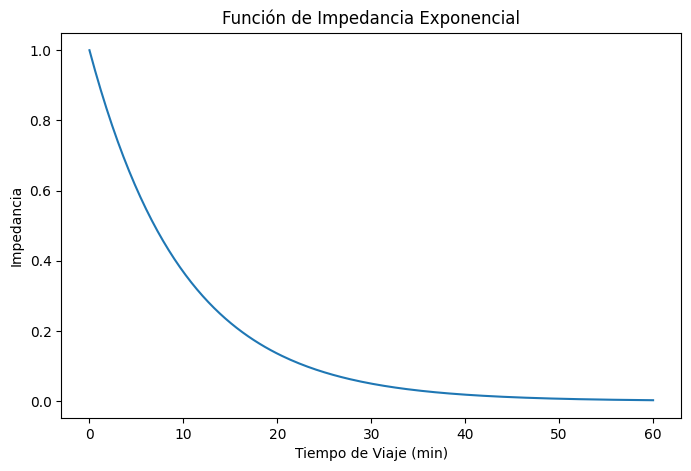

In [9]:
import matplotlib.pyplot as plt

def calcular_impedancia(costo_ij, phi):
    """
    crea una función de impedancia que decae exponencialmente con el costo (distancia/tiempo).
    """
    return np.exp(costo_ij*phi)

# graficar la función de impedancia
tiempos = np.linspace(0, 60, 200)  
phi = -0.1
impedancia_vals = calcular_impedancia(tiempos, phi)

plt.figure(figsize=(8,5))
plt.plot(tiempos, impedancia_vals)
plt.title("Función de Impedancia Exponencial")
plt.xlabel("Tiempo de Viaje (min)")
plt.ylabel("Impedancia")
plt.show()

In [21]:
drive_matrix_rm = pd.read_csv(
    "drive_matrix_rm.csv",
    index_col=0
)

walk_matrix_rm = pd.read_csv(
    "walk_matrix_rm.csv",
    index_col=0
)

drive_matrix_rm.columns = drive_matrix_rm.columns.astype(int)
walk_matrix_rm.columns = walk_matrix_rm.columns.astype(int)

In [22]:
# parámetro de impedancia utilizado en el laboratorio
phi_lab = -0.5

# calcular la impedancia para cada matriz
impedance_auto = drive_matrix_rm.map(
    calcular_impedancia,
    phi=phi_lab
)

impedance_caminata = walk_matrix_rm.map(
    calcular_impedancia,
    phi=phi_lab
)

# visualizar primeras filas
impedance_auto.iloc[:5, :5]

,0,1,2,3,4
0,1.000000,0.000005,0.030323,0.000010,0.019223
1,0.000003,1.000000,0.000078,0.059606,0.000062
2,0.043211,0.000056,1.000000,0.000211,0.162974
3,0.000022,0.047280,0.000520,1.000000,0.000175
4,0.017350,0.000101,0.132324,0.000165,1.000000


In [18]:
# exportar impedancias (anexo)
impedance_auto.to_json("anexos/impedance_auto.json")
impedance_caminata.to_json("anexos/impedance_caminata.json")

---

## 7. Cálculo de Accesibilidades Gravitacionales

Usando la matriz de impedancias calculada previamente $F_{i,j}^{m}$ y las variables de interés $N_{j}^{p}$ (p. ej., los usos de suelo) calculamos las accesibilidades para cada celda y cada variable de interés. Nuestro DataFrame resultante tendrá columnas nuevas, como acc_drive_m2_comercio, acc_drive_m2_industria, etc., representando la accesibilidad desde cada celda a la suma de esos usos de suelo, penalizados por la distancia/tiempo.

<br>

In [24]:
# filtrar por variables y multiplicación matricial con .dot()
variables = ['m2_comercio', 'm2_departamento', 'n_deporte_y_recreacion', 'n_educacion_y_cultura', 'm2_habitacional', 'm2_industria', 'm2_oficina', 'n_salud', 'n_paraderos']

accesibilidades_auto = impedance_auto.dot(celdas[variables])
accesibilidades_caminata = impedance_caminata.dot(celdas[variables])

# renombrar columnas
accesibilidades_auto.columns = [f"acc_auto_{col}" for col in accesibilidades_auto.columns]
accesibilidades_caminata.columns = [f"acc_caminata_{col}" for col in accesibilidades_caminata.columns]

# agregar geometría
accesibilidades_auto = celdas[['h3', 'geometry']].merge(accesibilidades_auto, left_index=True, right_index=True, how='left')
accesibilidades_caminata = celdas[['h3', 'geometry']].merge(accesibilidades_caminata, left_index=True, right_index=True, how='left')

In [25]:
# visualizar accesibilidades en automóvil a m2 construidos de comercio
accesibilidades_auto.explore(column='acc_auto_m2_comercio', scheme='NaturalBreaks', k=10)

In [26]:
# visualizar accesibilidades en caminata a m2 construidos de comercio
accesibilidades_caminata.explore(column='acc_caminata_m2_comercio', scheme='NaturalBreaks', k=10)

---

## 8. Guardar los Datos Procesados

Finalmente, podemos guardar un archivo con las columnas de accesibilidad calculadas. También podríamos combinar ambos resultados en un mismo GeoDataFrame, manteniendo columnas como acc_drive_m2_comercio, acc_walk_m2_comercio, etc., y exportarlo unificado.

<br>

In [27]:
# exportar los GeoDataFrame de accesibilidades a un archivo GeoJSON
accesibilidades_auto.to_file("celdas_accesibilidades_auto.geojson")
accesibilidades_caminata.to_file("celdas_accesibilidades_caminata.geojson")

**Fin del Laboratorio 3**

---

En el próximo laboratorio, exploraremos cómo estas métricas de accesibilidad pueden integrarse en modelos de localización basados en un enfoque *bid* y *choice*.

### 9. Anexo – Función para Recalcular Accesibilidades

En este laboratorio calculamos matrices de tiempos de viaje (y luego de impedancia) entre todas las celdas, asumiendo una red vial/peatonal fija y centroides de celdas que no cambian. Bajo esta suposición, las matrices de impedancia (`impedance_auto` e `impedance_caminata`) son **siempre las mismas**, incluso si actualizamos los atributos de las celdas (por ejemplo, m2 de comercio, m2 habitacional, etc.), o si trabajamos con distintos cortes temporales (por ejemplo, año 2017 v/s año 2025),

En otras palabras, si la red y los centroides no cambian, solo cambian los metros cuadrados y unidades de los diferentes tipos de uso de suelo ($N_j^p$), no los costos ($C_{i,j}^m$). Por lo tanto, podemos reutilizar las mismas matrices de impedancia una y otra vez para calcular accesibilidades en distintos escenarios, lo que puede ser muy útil para el Laboratorio 5 al momento de generar el motor de simulación.

In [28]:
# función para crear celdas con información agregada por año
def crear_celdas_con_informacion_por_año(agentes, celdas_area, año):
    agentes = agentes[agentes['año'] <= año]
    celdas_h3_pivot = agentes.pivot_table(
            index='h3',
            columns='destino',
            aggfunc={'superficie_construida': 'sum', 'destino': 'count'},
            fill_value=0).reset_index()

    celdas_h3_pivot.columns = [
        (col[0].replace('superficie_construida', 'm2_') + col[1] if 'superficie_construida' in col[0] else 'n_' + col[1] if col[0] == 'destino' else col[0])
        for col in celdas_h3_pivot.columns
    ]
    celdas_h3_pivot = celdas_area.merge(celdas_h3_pivot, on='h3', how='left')
    celdas_h3_pivot = celdas_h3_pivot.fillna(0)
    celdas_h3_pivot = gpd.GeoDataFrame(celdas_h3_pivot, geometry='geometry')
    return celdas_h3_pivot

# función para calcular accesibilidades
def calcular_accesibilidades(celdas, variables, impedance_matrix, prefix):
    accesibilidades = impedance_matrix.dot(celdas[variables])
    accesibilidades.columns = [f"{prefix}_{col}" for col in accesibilidades.columns]
    accesibilidades = celdas[['h3', 'geometry']].merge(accesibilidades, left_index=True, right_index=True, how='left')
    return accesibilidades

#### Construcción de cortes temporales

Comparación temporal 2017–2022

Como aplicación de las funciones anteriores, se construyen dos cortes temporales
para 2017 y 2022. Se utiliza 2022 como año final debido a que corresponde al último
año disponible en la base utilizada.

Para asegurar consistencia con las matrices de impedancia calculadas previamente,
se conservan únicamente las 1.017 celdas H3 correspondientes al área de análisis
Rancagua–Machalí y se mantiene su mismo orden.

In [29]:
import geopandas as gpd

# Cargar los agentes generados en el Lab 1
agentes = gpd.read_file("../lab_01/anexos/agentes.geojson")

# Conservar las mismas H3 y el mismo orden de celdas
celdas_area_rm = (
    celdas[['h3', 'geometry']]
    .copy()
    .reset_index(drop=True)
)

# Crear celdas con información agregada por año
celdas_2017 = crear_celdas_con_informacion_por_año(
    agentes, celdas_area_rm, 2017
)

celdas_2022 = crear_celdas_con_informacion_por_año(
    agentes, celdas_area_rm, 2022
)

In [30]:
cols_habitacional = [
    'm2_habitacional_cat1',
    'm2_habitacional_cat2',
    'm2_habitacional_cat3',
]

paraderos_por_h3 = celdas.set_index('h3')['n_paraderos']

for tabla in [celdas_2017, celdas_2022]:
    tabla['m2_habitacional'] = (
        tabla[cols_habitacional].sum(axis=1)
    )
    tabla['n_paraderos'] = tabla['h3'].map(paraderos_por_h3)

#### Cálculo de accesibilidades por año

In [31]:
variables_interes = [
    'm2_comercio',
    'm2_departamento',
    'n_deporte_y_recreacion',
    'n_educacion_y_cultura',
    'm2_habitacional_cat1',
    'm2_habitacional_cat2',
    'm2_habitacional_cat3',
    'm2_industria',
    'm2_oficina',
    'n_salud'
]
for var in variables_interes:
    if var in celdas_2017.columns:
        total_2017 = celdas_2017[var].sum()
        total_2022 = celdas_2022[var].sum()
        
        print(
            f"{var}: "
            f"2017 = {total_2017:.0f} | "
            f"2022 = {total_2022:.0f} | "
            f"cambio = {total_2022-total_2017:.0f}"
        )
    else:
        print(f"{var}: NO EXISTE")

m2_comercio: 2017 = 1510471 | 2022 = 1561044 | cambio = 50573
m2_departamento: 2017 = 1073776 | 2022 = 1297405 | cambio = 223629
n_deporte_y_recreacion: 2017 = 210 | 2022 = 226 | cambio = 16
n_educacion_y_cultura: 2017 = 1278 | 2022 = 1338 | cambio = 60
m2_habitacional_cat1: 2017 = 2158950 | 2022 = 2353556 | cambio = 194606
m2_habitacional_cat2: 2017 = 2507043 | 2022 = 2669975 | cambio = 162932
m2_habitacional_cat3: 2017 = 1282780 | 2022 = 1365029 | cambio = 82249
m2_industria: 2017 = 220623 | 2022 = 225540 | cambio = 4917
m2_oficina: 2017 = 278655 | 2022 = 311436 | cambio = 32781
n_salud: 2017 = 433 | 2022 = 452 | cambio = 19


Al mantenerse constantes las matrices de impedancia, las diferencias de
accesibilidad entre ambos años responden únicamente a cambios en la cantidad
y distribución espacial de las oportunidades consideradas.

In [32]:
# accesibilidades 2017
acc_auto_2017 = calcular_accesibilidades(
    celdas_2017,
    variables,
    impedance_auto,
    prefix='acc_auto'
)

acc_caminata_2017 = calcular_accesibilidades(
    celdas_2017,
    variables,
    impedance_caminata,
    prefix='acc_caminata'
)

# accesibilidades 2022
acc_auto_2022 = calcular_accesibilidades(
    celdas_2022,
    variables,
    impedance_auto,
    prefix='acc_auto'
)

acc_caminata_2022 = calcular_accesibilidades(
    celdas_2022,
    variables,
    impedance_caminata,
    prefix='acc_caminata'
)

#### Comparación temporal de accesibilidades

A partir de las accesibilidades calculadas para 2017 y 2022, se define una función
general que permite cuantificar el cambio de accesibilidad experimentado por cada
celda H3 entre ambos años.

La función puede aplicarse a cualquiera de las variables consideradas en el análisis.
Para ello, se deben entregar las accesibilidades correspondientes a ambos años y
especificar la columna de la oportunidad que se desea analizar.

##### Función para calcular cambios de accesibilidad

In [33]:
def calcular_cambio_accesibilidad(acc_2017, acc_2022, columna):
    
    cambio = acc_2022[['h3', 'geometry', columna]].copy()
    
    cambio['acc_2017'] = acc_2017[columna].values
    cambio['acc_2022'] = acc_2022[columna].values
    
    cambio['cambio_accesibilidad'] = (
        cambio['acc_2022'] - cambio['acc_2017']
    )
    
    return cambio

La función genera, para cada celda, tres variables: la accesibilidad en 2017,
la accesibilidad en 2022 y su diferencia. Un valor positivo de
`cambio_accesibilidad` representa un aumento de la accesibilidad entre ambos
años, mientras que un valor negativo representa una disminución.

La variable analizada se selecciona mediante el argumento `columna`, por lo que
la misma función puede reutilizarse para estudiar distintos tipos de oportunidades
y ambos modos de transporte.

##### Ejemplo de aplicación: accesibilidad al comercio

Como ejemplo, se analiza la evolución de la accesibilidad a la superficie construida
destinada a comercio. Para automóvil se utiliza la variable
`acc_auto_m2_comercio`, mientras que para caminata se utiliza
`acc_caminata_m2_comercio`.

In [34]:
# cambio de accesibilidad al comercio en automóvil
cambio_auto = calcular_cambio_accesibilidad(
    acc_auto_2017,
    acc_auto_2022,
    'acc_auto_m2_comercio'
)

# cambio de accesibilidad al comercio caminando
cambio_caminata = calcular_cambio_accesibilidad(
    acc_caminata_2017,
    acc_caminata_2022,
    'acc_caminata_m2_comercio'
)

In [35]:
cambio_auto.explore(
    column='cambio_accesibilidad',
    scheme='NaturalBreaks',
    k=7,
    legend=True,
    tooltip=[
        'h3',
        'acc_2017',
        'acc_2022',
        'cambio_accesibilidad'
    ],
    legend_kwds={
        'caption': 'Cambio accesibilidad al comercio - Auto'
    }
)

In [36]:
cambio_caminata.explore(
    column='cambio_accesibilidad',
    scheme='NaturalBreaks',
    k=7,
    legend=True,
    tooltip=[
        'h3',
        'acc_2017',
        'acc_2022',
        'cambio_accesibilidad'
    ],
    legend_kwds={
        'caption': 'Cambio accesibilidad al comercio - Caminata'
    }
)

##### Aplicación a otras oportunidades

El procedimiento anterior no se limita al comercio. Para estudiar otra oportunidad solo es necesario modificar la columna entregada a la función. La columna depende tanto del modo de transporte (`acc_auto_` o `acc_caminata_`) como de la variable de oportunidad considerada.

Por ejemplo, para analizar accesibilidad a establecimientos de salud se utiliza `acc_auto_n_salud` en automóvil o `acc_caminata_n_salud` en caminata.

In [37]:
# salud en automóvil
cambio_salud_auto = calcular_cambio_accesibilidad(
    acc_auto_2017,
    acc_auto_2022,
    'acc_auto_n_salud')

# salud en caminata
cambio_salud_caminata = calcular_cambio_accesibilidad(
    acc_caminata_2017,
    acc_caminata_2022,
    'acc_caminata_n_salud'
)

# educación y cultura en automóvil
cambio_educacion_auto = calcular_cambio_accesibilidad(
    acc_auto_2017,
    acc_auto_2022,
    'acc_auto_n_educacion_y_cultura'
)

# oficinas caminando
cambio_oficinas_caminata = calcular_cambio_accesibilidad(
    acc_caminata_2017,
    acc_caminata_2022,
    'acc_caminata_m2_oficina'
)

In [38]:
cambio_salud_auto.explore(
    column='cambio_accesibilidad',
    scheme='NaturalBreaks',
    k=7,
    legend=True,
    tooltip=[
        'h3',
        'acc_2017',
        'acc_2022',
        'cambio_accesibilidad'
    ],
    legend_kwds={
        'caption': 'Cambio accesibilidad a salud - Auto'
    }
)

In [39]:
cambio_salud_caminata.explore(
    column='cambio_accesibilidad',
    scheme='NaturalBreaks',
    k=7,
    legend=True,
    tooltip=[
        'h3',
        'acc_2017',
        'acc_2022',
        'cambio_accesibilidad'
    ],
    legend_kwds={
        'caption': 'Cambio accesibilidad a salud - Caminata'
    }
)

### Análisis de sensibilidad de la función de impedancia

El cálculo de accesibilidad gravitacional depende de la función de impedancia utilizada
para representar el efecto del costo de viaje sobre el acceso a las oportunidades. En
este laboratorio se utiliza una función exponencial:

\[
f(c_{ij}) = e^{\phi c_{ij}}
\]

donde \(c_{ij}\) corresponde al tiempo de viaje entre las celdas \(i\) y \(j\), y
\(\phi\) determina la rapidez con que disminuye el peso de una oportunidad a medida
que aumenta el tiempo de viaje.

Dado que la elección de \(\phi\) puede modificar considerablemente los resultados de
accesibilidad, se realiza un análisis de sensibilidad para distintos valores del
parámetro.

#### 1. Comparar distintas curvas

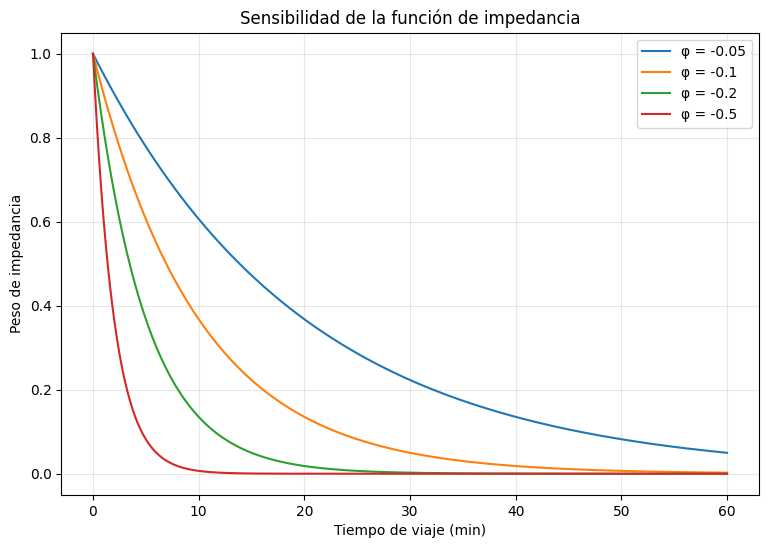

In [40]:
phis = [-0.05, -0.1, -0.2, -0.5]
tiempos = np.linspace(0, 60, 300)
phis = [-0.05, -0.1, -0.2, -0.5]

plt.figure(figsize=(9, 6))

for phi in phis:
    plt.plot(
        tiempos,
        calcular_impedancia(tiempos, phi),
        label=f'φ = {phi}'
    )

plt.title('Sensibilidad de la función de impedancia')
plt.xlabel('Tiempo de viaje (min)')
plt.ylabel('Peso de impedancia')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Hagamos también una tabla

In [41]:
tiempos_referencia = [0, 5, 10, 15, 20, 30, 45, 60]

tabla_impedancia = pd.DataFrame({
    f'phi_{phi}': [
        calcular_impedancia(t, phi)
        for t in tiempos_referencia
    ]
    for phi in phis
}, index=tiempos_referencia)

tabla_impedancia.index.name = 'tiempo_min'

tabla_impedancia.round(4)

,phi_-0.05,phi_-0.1,phi_-0.2,phi_-0.5
tiempo_min,,,,
0,1.0000,1.0000,1.0000,1.0000
5,0.7788,0.6065,0.3679,0.0821
10,0.6065,0.3679,0.1353,0.0067
15,0.4724,0.2231,0.0498,0.0006
20,0.3679,0.1353,0.0183,0.0000
30,0.2231,0.0498,0.0025,0.0000
45,0.1054,0.0111,0.0001,0.0000
60,0.0498,0.0025,0.0000,0.0000


In [42]:
for phi in phis:
    t50 = np.log(0.5) / phi
    print(f"φ = {phi:>5}: peso 50% a los {t50:.2f} minutos")

φ = -0.05: peso 50% a los 13.86 minutos
φ =  -0.1: peso 50% a los 6.93 minutos
φ =  -0.2: peso 50% a los 3.47 minutos
φ =  -0.5: peso 50% a los 1.39 minutos


El φ=-0.5 equivale a decir que una oportunidad pierde la mitad de su peso cada 1,39 minutos de viaje.

#### Efecto del parámetro de impedancia sobre la accesibilidad

Para evaluar la sensibilidad de los resultados al parámetro de impedancia, se
recalcula la accesibilidad al comercio utilizando distintos valores de \(\phi\),
manteniendo constantes tanto la matriz de tiempos de viaje como la distribución
de oportunidades.

De esta forma, cualquier diferencia observada en los resultados corresponde
exclusivamente al efecto del parámetro de impedancia.

In [44]:
phis = [-0.05, -0.1, -0.2, -0.5]

sensibilidad_auto = celdas[['h3', 'geometry']].copy()

for phi in phis:
    
    # matriz de impedancia para este phi
    imp_phi = drive_matrix_rm.map(
        calcular_impedancia,
        phi=phi
    )
    
    # accesibilidad al comercio
    sensibilidad_auto[f'acc_phi_{phi}'] = (
        imp_phi.dot(celdas['m2_comercio'])
    )

In [45]:
sensibilidad_auto[
    ['acc_phi_-0.05',
     'acc_phi_-0.1',
     'acc_phi_-0.2',
     'acc_phi_-0.5']
].describe()

,acc_phi_-0.05,acc_phi_-0.1,acc_phi_-0.2,acc_phi_-0.5
count,8.800000e+02,8.800000e+02,880.000000,880.000000
mean,9.611685e+05,6.220032e+05,293800.223933,58058.526538
std,1.721291e+05,2.055871e+05,168011.618128,59371.782500
min,4.596608e+05,1.385872e+05,13627.189311,62.862892
25%,8.269874e+05,4.495074e+05,144005.834002,10833.829938
50%,9.832345e+05,6.309890e+05,274806.223986,34676.522978
75%,1.107082e+06,7.962564e+05,434087.616471,90304.391200
max,1.246008e+06,1.005747e+06,674704.985651,247843.685769


In [46]:
sensibilidad_auto.explore(
    column='acc_phi_-0.05',
    scheme='NaturalBreaks',
    k=7,
    legend=True,
    tooltip=[
        'h3',
        'acc_phi_-0.05'
    ],
    legend_kwds={
        'caption': 'Accesibilidad al comercio - φ = -0.05'
    }
)

In [47]:
sensibilidad_auto.explore(
    column='acc_phi_-0.5',
    scheme='NaturalBreaks',
    k=7,
    legend=True,
    tooltip=[
        'h3',
        'acc_phi_-0.5'
    ],
    legend_kwds={
        'caption': 'Accesibilidad al comercio - φ = -0.5'
    }
)

In [64]:
agentes_estimacion = agentes[
    (agentes['año'] >= 2018) &
    (agentes['año'] <= 2022)
].copy()

print("Número de agentes:", len(agentes_estimacion))
print("\nAgentes por año:")
print(agentes_estimacion.groupby('año').size())

Número de agentes: 16380

Agentes por año:
año
2018.0    3690
2019.0    4103
2020.0    4715
2021.0    2604
2022.0    1268
dtype: int64


In [55]:
# columnas de accesibilidad
cols_acc_auto = [
    col for col in accesibilidades_auto.columns
    if col.startswith('acc_auto_')
]

cols_acc_caminata = [
    col for col in accesibilidades_caminata.columns
    if col.startswith('acc_caminata_')
]

print(cols_acc_auto)
print(cols_acc_caminata)

['acc_auto_m2_comercio', 'acc_auto_m2_departamento', 'acc_auto_n_deporte_y_recreacion', 'acc_auto_n_educacion_y_cultura', 'acc_auto_m2_habitacional', 'acc_auto_m2_industria', 'acc_auto_m2_oficina', 'acc_auto_n_salud', 'acc_auto_n_paraderos']
['acc_caminata_m2_comercio', 'acc_caminata_m2_departamento', 'acc_caminata_n_deporte_y_recreacion', 'acc_caminata_n_educacion_y_cultura', 'acc_caminata_m2_habitacional', 'acc_caminata_m2_industria', 'acc_caminata_m2_oficina', 'acc_caminata_n_salud', 'acc_caminata_n_paraderos']


In [56]:
celdas_estimacion = celdas.copy()

celdas_estimacion = celdas_estimacion.merge(
    accesibilidades_auto[['h3'] + cols_acc_auto],
    on='h3',
    how='left'
)

celdas_estimacion = celdas_estimacion.merge(
    accesibilidades_caminata[['h3'] + cols_acc_caminata],
    on='h3',
    how='left'
)

In [57]:
print(celdas_estimacion.shape)

print(
    "Accesibilidades auto:",
    len(cols_acc_auto)
)

print(
    "Accesibilidades caminata:",
    len(cols_acc_caminata)
)

print(
    "NaN accesibilidades:",
    celdas_estimacion[cols_acc_auto + cols_acc_caminata]
    .isna().sum().sum()
)

(880, 79)
Accesibilidades auto: 9
Accesibilidades caminata: 9
NaN accesibilidades: 0


In [58]:
print(celdas_estimacion.columns.tolist())

['h3', 'n_adm._publica_y_defensa', 'n_agricola_por_asimilacion', 'n_bienes_comunes', 'n_bodega_y_almacenaje', 'n_comercio', 'n_culto', 'n_departamento', 'n_deporte_y_recreacion', 'n_educacion_y_cultura', 'n_estacionamiento', 'n_habitacional_cat1', 'n_habitacional_cat2', 'n_habitacional_cat3', 'n_habitacional_no_considerado', 'n_hotel,_motel', 'n_industria', 'n_oficina', 'n_otros_no_considerados', 'n_salud', 'n_sitio_eriazo', 'n_transporte_y_telec.', 'm2_adm._publica_y_defensa', 'm2_agricola_por_asimilacion', 'm2_bienes_comunes', 'm2_bodega_y_almacenaje', 'm2_comercio', 'm2_culto', 'm2_departamento', 'm2_deporte_y_recreacion', 'm2_educacion_y_cultura', 'm2_estacionamiento', 'm2_habitacional_cat1', 'm2_habitacional_cat2', 'm2_habitacional_cat3', 'm2_habitacional_no_considerado', 'm2_hotel,_motel', 'm2_industria', 'm2_oficina', 'm2_otros_no_considerados', 'm2_salud', 'm2_sitio_eriazo', 'm2_transporte_y_telec.', 'personas', 'viviendas', 'hogares', 'n_paraderos', 'm2_habitacional', 'area_ha

In [60]:
celdas_estimacion.to_file(
    "celdas_estimacion.geojson",
    driver="GeoJSON"
)

In [61]:
test = gpd.read_file("celdas_estimacion.geojson")

print(test.shape)
print(test.crs)
print(test['h3'].nunique())

(880, 79)
EPSG:4326
880
